# Pipeline DT

In [169]:
# importazione librerie necessarie
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import gzip
import numpy as np

# modello da allenare (Decision Tree)
from sklearn.tree import DecisionTreeClassifier

# importazione metriche di valutazione e utilità al fine dell'allenamento dei modelli
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

# # per visualizzare il decision tree
# from sklearn.tree import export_graphviz
# from six import StringIO 
# from IPython.display import Image  
# import pydotplus

# per fare Oversampling/Undersampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [170]:
# features variabili su cui andare ad allenare i modelli (DA CAMBIARE PER RUN DIVERSE) [DATASET NON NORMALIZZATO]
features = ['avg_position','avg_position_1','avg_position_2','avg_position_3','avg_position_4','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','avg_position_1','avg_position_2','avg_position_3','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','avg_position_1','avg_position_2','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','avg_position_1','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']

In [171]:
# features variabili su cui andare ad allenare i modelli (DA CAMBIARE PER RUN DIVERSE) [DATASET NORMALIZZATO]
features_n = ['avg_position_startlist','avg_position_1_startlist','avg_position_2_startlist','avg_position_3_startlist','avg_position_4_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','avg_position_1_startlist','avg_position_2_startlist','avg_position_3_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','avg_position_1_startlist','avg_position_2_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','avg_position_1_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']

In [172]:
# DATA TO SAVE IN ADDITION TO CLASSIFICATION REPORT AND CONFUSION MATRIX FOR EACH MODEL

# model_name = ""
# dataset = ""
# features_dataset = []

##  Not normalized dataset

Best Hyperparameters:
criterion="entropy",splitter="best",max_depth=10,min_samples_split=2,min_samples_leaf=5,class_weight="balanced,random_state=42"

In [173]:
# Take the merged dataset cleaned from null values and anomalies
with gzip.open('../../dataset/train_set.pkl', 'r') as file:
    train_set = pickle.load(file)
with gzip.open('../../dataset/test_set.pkl', 'r') as file:
    test_set = pickle.load(file)

In [174]:
model_name = "DT"
dataset = "dataset_non_normalizzato"
features_dataset = features

In [175]:
print("Train_set shape before dropping NaN:",train_set.shape)
print("Test_set shape before dropping NaN:",test_set.shape)
train_set = train_set.dropna()
test_set = test_set.dropna()
print("Train_set shape post dropping NaN:",train_set.shape)
print("Test_set shape post dropping NaN:",test_set.shape)

X_train = train_set[features]
y_train = train_set['top20']

X_test = test_set[features]
y_test = test_set['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (405899, 35)
Test_set shape before dropping NaN: (35406, 35)
Train_set shape post dropping NaN: (390572, 35)
Test_set shape post dropping NaN: (34258, 35)
X_train shape: (390572, 9)
y_train shape: (390572,)
X_test shape: (34258, 9)
y_test shape: (34258,)


In [176]:
# BEST model
DT = DecisionTreeClassifier(criterion="entropy",splitter="best",max_depth=10,min_samples_split=2,min_samples_leaf=5,class_weight="balanced",random_state=42)     

In [177]:
DT.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=10, min_samples_leaf=5, random_state=42)

In [178]:
y_train_pred = DT.predict(X_train)
scores = classification_report(y_train,y_train_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.94      0.71      0.81    336829
           1       0.28      0.73      0.41     53743

    accuracy                           0.71    390572
   macro avg       0.61      0.72      0.61    390572
weighted avg       0.85      0.71      0.75    390572



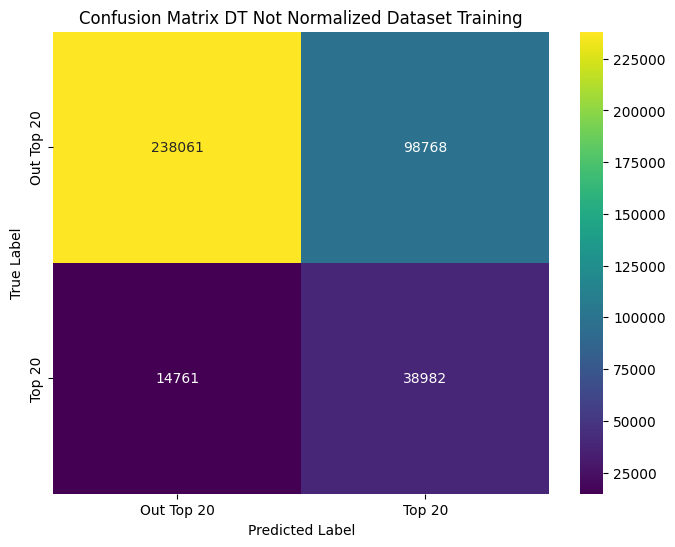

In [179]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix DT Not Normalized Dataset Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [180]:
y_pred = DT.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.94      0.65      0.77     29163
           1       0.27      0.75      0.40      5095

    accuracy                           0.66     34258
   macro avg       0.60      0.70      0.58     34258
weighted avg       0.84      0.66      0.71     34258



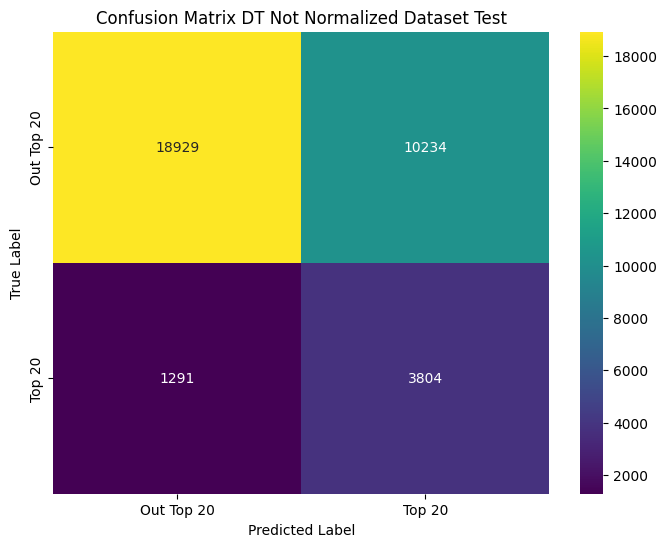

In [181]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix DT Not Normalized Dataset Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [182]:
# # save results
# with open("./stuffs/results/GS/DT_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

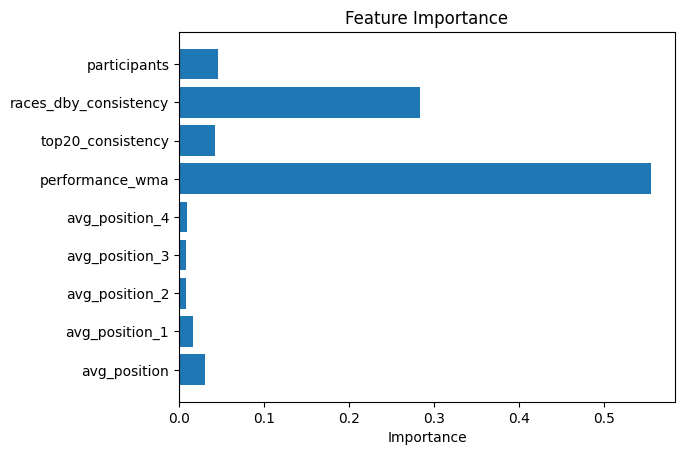

In [183]:
import matplotlib.pyplot as plt

importance = DT.feature_importances_

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

### Oversampling/Undersampling

In [184]:
model_name = "DT"
dataset = "dataset_non_normalizzato_con_oversampling"
features_dataset = features

In [185]:
print("Train_set shape before dropping NaN:",train_set.shape)
print("Test_set shape before dropping NaN:",test_set.shape)
train_set = train_set.dropna()
test_set = test_set.dropna()
print("Train_set shape post dropping NaN:",train_set.shape)
print("Test_set shape post dropping NaN:",test_set.shape)

X_train = train_set[features]
y_train = train_set['top20']

X_test = test_set[features]
y_test = test_set['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (390572, 35)
Test_set shape before dropping NaN: (34258, 35)
Train_set shape post dropping NaN: (390572, 35)
Test_set shape post dropping NaN: (34258, 35)
X_train shape: (390572, 9)
y_train shape: (390572,)
X_test shape: (34258, 9)
y_test shape: (34258,)


In [186]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 336829, 1: 53743})


In [187]:
# Applica SMOTE (Oversampling)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [188]:
# Controlla la distribuzione dopo SMOTE
print("Distribuzione dopo SMOTE:", Counter(y_train_resampled))

Distribuzione dopo SMOTE: Counter({1: 336829, 0: 336829})


In [189]:
# BEST model
DT = DecisionTreeClassifier(criterion="entropy",splitter="best",max_depth=10,min_samples_split=2,min_samples_leaf=5,class_weight="balanced",random_state=42)     

In [190]:
DT.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=10, min_samples_leaf=5, random_state=42)

In [191]:
y_train_resampled_pred = DT.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.71      0.77      0.74    336829
           1       0.75      0.69      0.72    336829

    accuracy                           0.73    673658
   macro avg       0.73      0.73      0.73    673658
weighted avg       0.73      0.73      0.73    673658



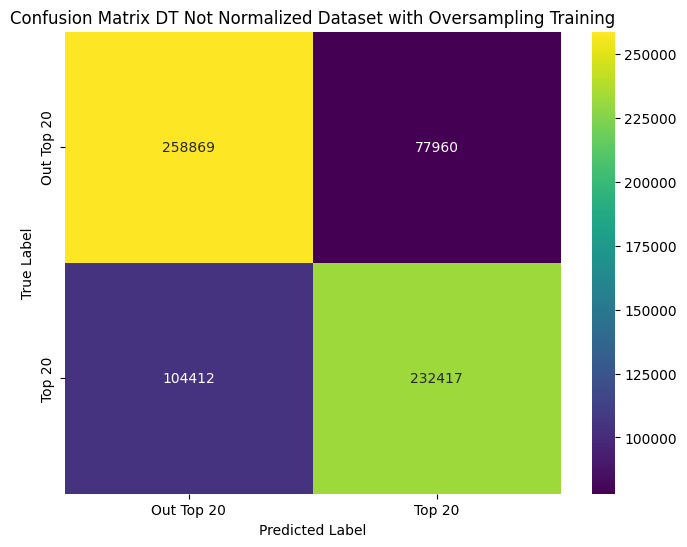

In [192]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix DT Not Normalized Dataset with Oversampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [193]:
y_pred = DT.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.93      0.70      0.80     29163
           1       0.29      0.69      0.41      5095

    accuracy                           0.70     34258
   macro avg       0.61      0.69      0.60     34258
weighted avg       0.83      0.70      0.74     34258



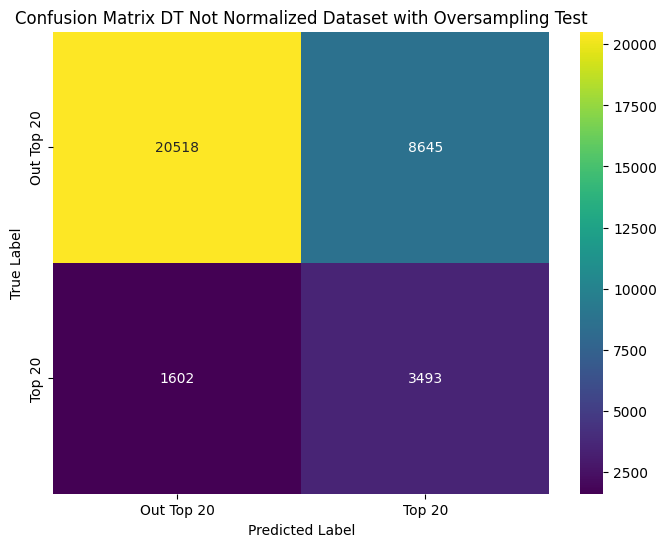

In [194]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix DT Not Normalized Dataset with Oversampling Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [195]:
# # save results
# with open("./stuffs/results/GS/DT_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

In [196]:
model_name = "DT"
dataset = "dataset_non_normalizzato_con_undersampling"
features_dataset = features

In [197]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 336829, 1: 53743})


In [198]:
# Applica Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [199]:
# Controlla la distribuzione dopo l'undersampling
print("Distribuzione dopo Random Undersampling:", Counter(y_train_resampled))

Distribuzione dopo Random Undersampling: Counter({0: 53743, 1: 53743})


In [200]:
# BEST model
DT = DecisionTreeClassifier(criterion="entropy",splitter="best",max_depth=10,min_samples_split=2,min_samples_leaf=5,class_weight="balanced",random_state=42)     

In [201]:
DT.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=10, min_samples_leaf=5, random_state=42)

In [202]:
y_train_resampled_pred = DT.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.72      0.71      0.72     53743
           1       0.72      0.73      0.72     53743

    accuracy                           0.72    107486
   macro avg       0.72      0.72      0.72    107486
weighted avg       0.72      0.72      0.72    107486



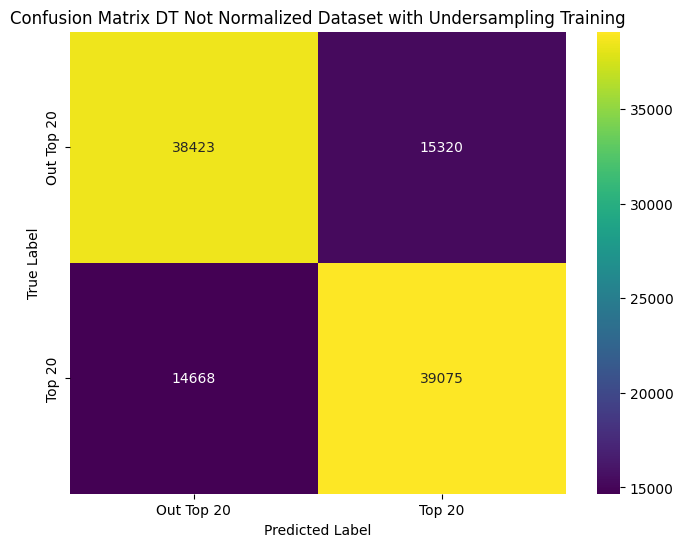

In [203]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix DT Not Normalized Dataset with Undersampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [204]:
y_pred = DT.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.94      0.64      0.76     29163
           1       0.27      0.75      0.39      5095

    accuracy                           0.66     34258
   macro avg       0.60      0.70      0.58     34258
weighted avg       0.84      0.66      0.71     34258



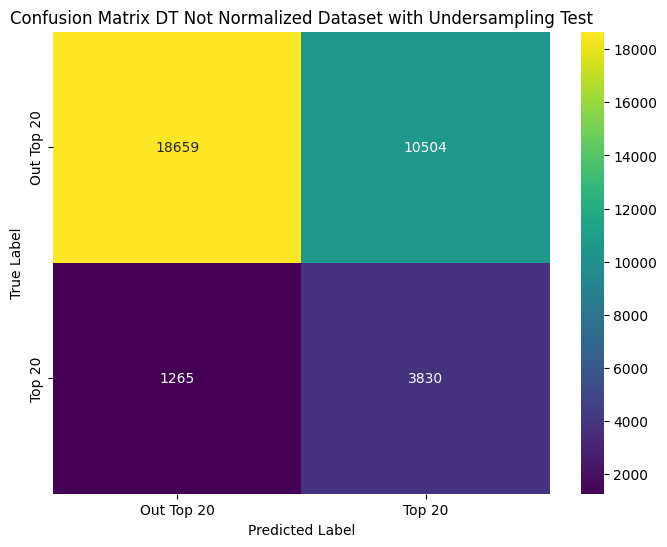

In [205]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix DT Not Normalized Dataset with Undersampling Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [206]:
# # save results
# with open("./stuffs/results/GS/DT_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

## Normalized dataset

Best Hyperparameters:
criterion="entropy",splitter="random",max_depth=10,min_samples_split=2,min_samples_leaf=1,class_weight="balanced,random_state=42"

In [207]:
# Take the normalized merged dataset cleaned from null values and anomalies
with gzip.open('../../dataset/train_set_normalized.pkl', 'r') as file:
    train_set_n = pickle.load(file)
with gzip.open('../../dataset/test_set_normalized.pkl', 'r') as file:
    test_set_n = pickle.load(file)

In [208]:
model_name = "DT"
dataset = "dataset_normalizzato"
features_dataset = features_n

In [209]:
print("Train_set shape before dropping NaN:",train_set_n.shape)
print("Test_set shape before dropping NaN:",test_set_n.shape)
train_set_n = train_set_n.dropna()
test_set_n = test_set_n.dropna()
print("Train_set shape post dropping NaN:",train_set_n.shape)
print("Test_set shape post dropping NaN:",test_set_n.shape)

X_train = train_set_n[features_n]
y_train = train_set_n['top20']

X_test = test_set_n[features_n]
y_test = test_set_n['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (405899, 37)
Test_set shape before dropping NaN: (35406, 37)
Train_set shape post dropping NaN: (394206, 37)
Test_set shape post dropping NaN: (34509, 37)
X_train shape: (394206, 9)
y_train shape: (394206,)
X_test shape: (34509, 9)
y_test shape: (34509,)


In [210]:
# BEST model
DT = DecisionTreeClassifier(criterion="entropy",splitter="random",max_depth=10,min_samples_split=2,min_samples_leaf=1,class_weight="balanced",random_state=42)     

In [211]:
DT.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=10, random_state=42, splitter='random')

In [212]:
y_train_pred = DT.predict(X_train)
scores = classification_report(y_train,y_train_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.94      0.69      0.79    340134
           1       0.27      0.72      0.39     54072

    accuracy                           0.69    394206
   macro avg       0.60      0.70      0.59    394206
weighted avg       0.85      0.69      0.74    394206



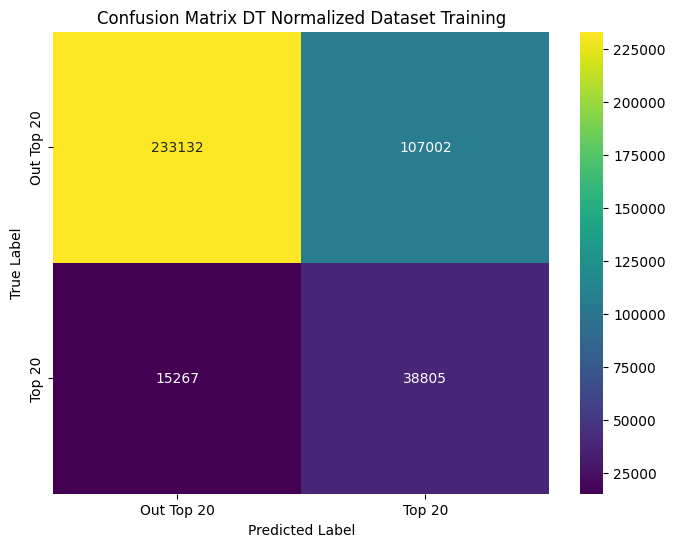

In [213]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix DT Normalized Dataset Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [214]:
y_pred = DT.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.93      0.66      0.77     29391
           1       0.27      0.73      0.40      5118

    accuracy                           0.67     34509
   macro avg       0.60      0.69      0.58     34509
weighted avg       0.84      0.67      0.72     34509



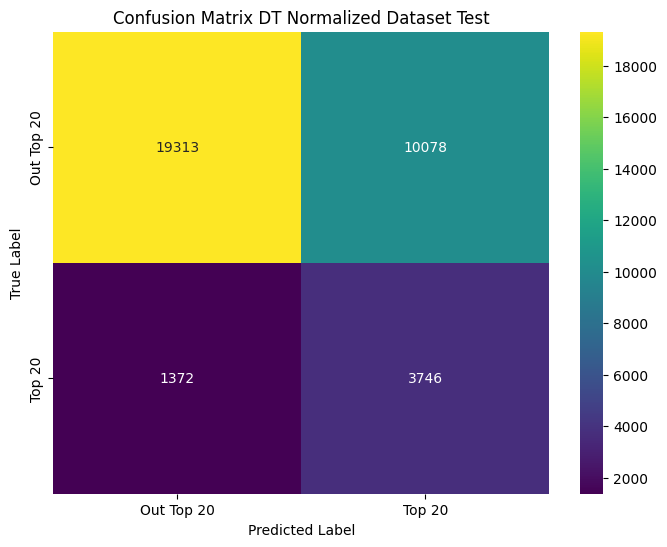

In [215]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix DT Normalized Dataset Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [216]:
# # save results
# with open("./stuffs/results/GS/DT_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

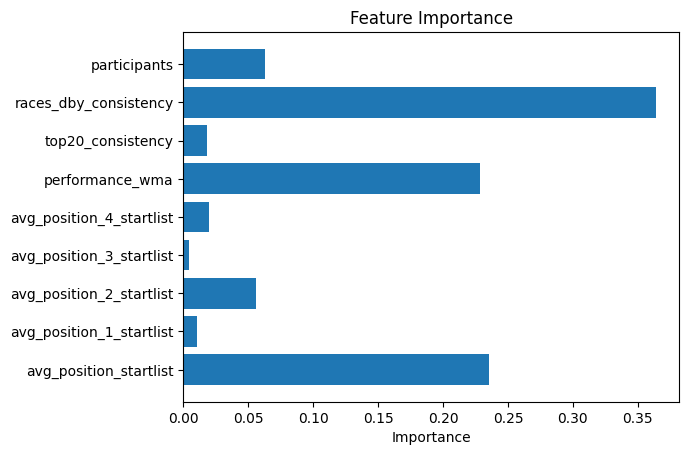

In [217]:
import matplotlib.pyplot as plt

importance = DT.feature_importances_

plt.barh(features_n, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

### Oversampling/Undersampling

In [218]:
model_name = "DT"
dataset = "dataset_normalizzato_con_oversampling"
features_dataset = features_n

In [219]:
print("Train_set shape before dropping NaN:",train_set_n.shape)
print("Test_set shape before dropping NaN:",test_set_n.shape)
train_set_n = train_set_n.dropna()
test_set_n = test_set_n.dropna()
print("Train_set shape post dropping NaN:",train_set_n.shape)
print("Test_set shape post dropping NaN:",test_set_n.shape)

X_train = train_set_n[features_n]
y_train = train_set_n['top20']

X_test = test_set_n[features_n]
y_test = test_set_n['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (394206, 37)
Test_set shape before dropping NaN: (34509, 37)
Train_set shape post dropping NaN: (394206, 37)
Test_set shape post dropping NaN: (34509, 37)
X_train shape: (394206, 9)
y_train shape: (394206,)
X_test shape: (34509, 9)
y_test shape: (34509,)


In [220]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 340134, 1: 54072})


In [221]:
# Applica SMOTE (Oversampling)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [222]:
# Controlla la distribuzione dopo SMOTE
print("Distribuzione dopo SMOTE:", Counter(y_train_resampled))

Distribuzione dopo SMOTE: Counter({1: 340134, 0: 340134})


In [223]:
# BEST model
DT = DecisionTreeClassifier(criterion="entropy",splitter="random",max_depth=10,min_samples_split=2,min_samples_leaf=1,class_weight="balanced",random_state=42)     

In [224]:
DT.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=10, random_state=42, splitter='random')

In [225]:
y_train_resampled_pred = DT.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.71      0.68      0.70    340134
           1       0.69      0.73      0.71    340134

    accuracy                           0.70    680268
   macro avg       0.70      0.70      0.70    680268
weighted avg       0.70      0.70      0.70    680268



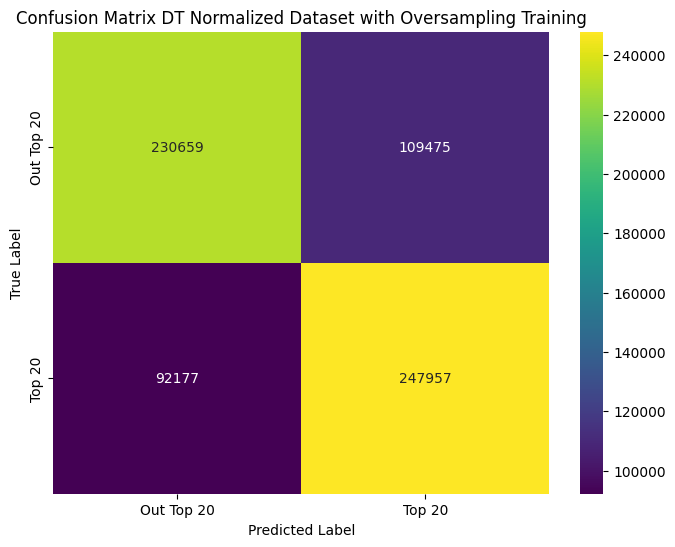

In [226]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix DT Normalized Dataset with Oversampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [227]:
y_pred = DT.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.93      0.64      0.76     29391
           1       0.26      0.72      0.38      5118

    accuracy                           0.65     34509
   macro avg       0.59      0.68      0.57     34509
weighted avg       0.83      0.65      0.70     34509



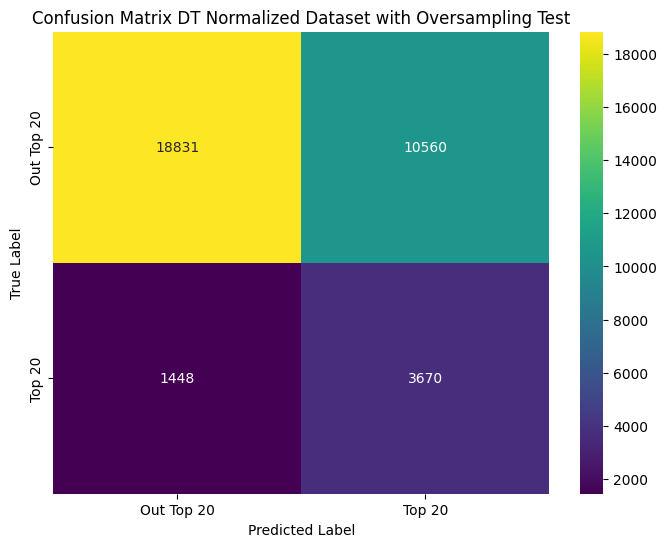

In [228]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix DT Normalized Dataset with Oversampling Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [229]:
# # save results
# with open("./stuffs/results/GS/DT_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

In [230]:
model_name = "DT"
dataset = "dataset_normalizzato_con_undersampling"
features_dataset = features_n

In [231]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 340134, 1: 54072})


In [232]:
# Applica Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [233]:
# Controlla la distribuzione dopo l'undersampling
print("Distribuzione dopo Random Undersampling:", Counter(y_train_resampled))

Distribuzione dopo Random Undersampling: Counter({0: 54072, 1: 54072})


In [234]:
# BEST model
DT = DecisionTreeClassifier(criterion="entropy",splitter="random",max_depth=10,min_samples_split=2,min_samples_leaf=1,class_weight="balanced",random_state=42)     

In [235]:
DT.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=10, random_state=42, splitter='random')

In [236]:
y_train_resampled_pred = DT.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.68      0.73      0.71     54072
           1       0.71      0.66      0.69     54072

    accuracy                           0.70    108144
   macro avg       0.70      0.70      0.70    108144
weighted avg       0.70      0.70      0.70    108144



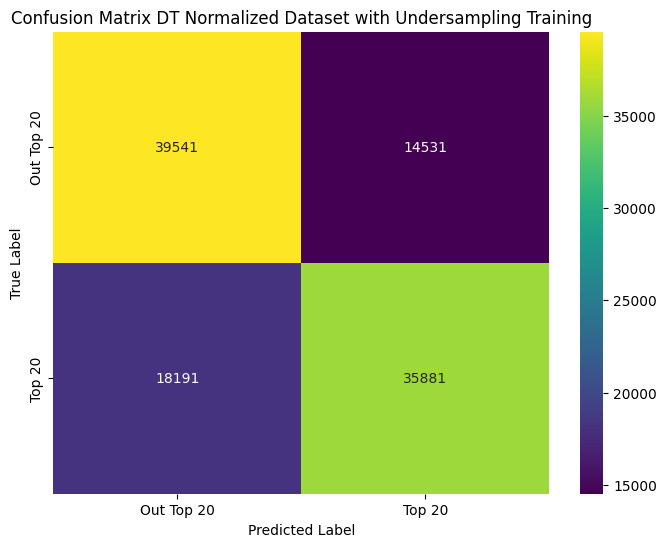

In [237]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix DT Normalized Dataset with Undersampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [238]:
y_pred = DT.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.93      0.68      0.78     29391
           1       0.28      0.71      0.40      5118

    accuracy                           0.68     34509
   macro avg       0.60      0.69      0.59     34509
weighted avg       0.83      0.68      0.73     34509



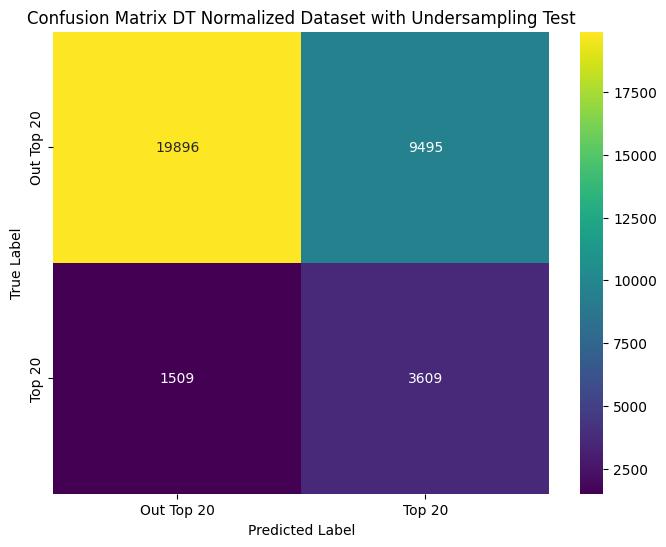

In [239]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix DT Normalized Dataset with Undersampling Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [240]:
# # save results
# with open("./stuffs/results/GS/DT_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")